In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import keras.backend as K
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout,BatchNormalization ,Activation
from tensorflow.keras.models import Model, Sequential
from keras.applications.nasnet import NASNetLarge
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from glob import glob
import os
from keras.callbacks import ModelCheckpoint, EarlyStopping,CSVLogger,ProgbarLogger

In [21]:
# IMAGE_SIZE = [224, 224]

# train_path = 'E:\\Capstone\\Dataset\\Gray_Img\\train'
# valid_path = 'E:\\Capstone\\Dataset\\Gray_Img\\test'

In [2]:
#here image size is 256x256
IMAGE_SIZE = 224
#every time process 32 images (61x31)~1951
BATCH_SIZE = 32
#how many color have in these pictures
CHANNELS = 3
#80x25~1951
EPOCHS = 100
NUM_CLASSES = 7
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
patience=10
data_dir ="E:\\Capstone\\Dataset\\Gray_Img\\images"

In [3]:
vgg16 = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), weights='imagenet', include_top=False)

In [4]:
for layer in vgg16.layers:
    layer.trainable = False

In [5]:
folders = glob('E:/Capstone/Dataset/Gray_Img/images/*')

In [6]:
folders

['E:/Capstone/Dataset/Gray_Img/images\\Angry',
 'E:/Capstone/Dataset/Gray_Img/images\\Disgust',
 'E:/Capstone/Dataset/Gray_Img/images\\Fear',
 'E:/Capstone/Dataset/Gray_Img/images\\Happy',
 'E:/Capstone/Dataset/Gray_Img/images\\Neutral',
 'E:/Capstone/Dataset/Gray_Img/images\\Sad',
 'E:/Capstone/Dataset/Gray_Img/images\\Surprise']

In [7]:
x = Flatten()(vgg16.output)

In [8]:
len(folders)

7

In [9]:
import tensorflow as tf



# Define image parameters
img_height = IMAGE_SIZE
img_width = img_height
batch_size = BATCH_SIZE

# Define data augmentation parameters
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 , # 20% of the data will be used for validation
    rotation_range=5,  # Rotate images randomly up to 20 degrees
    # Zoom range [1-zoom_range, 1+zoom_range]
    #horizontal_flip=True,  # Flip images horizontally
    #vertical_flip=True  # Flip images vertically
     # Strategy used for filling in newly created pixels
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    # zoom_range=0.2,
    horizontal_flip=True,
    # vertical_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Update for multi-class classification
    subset='training'  # specify that this generator will be used for training data
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Update for multi-class classification
    subset='validation'  # specify that this generator will be used for validation data
)

Found 16126 images belonging to 7 classes.
Found 4031 images belonging to 7 classes.


In [10]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=vgg16.input, outputs=prediction)

In [38]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [11]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [12]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# train_datagen = ImageDataGenerator(rescale = 1./255,
#                                    shear_range = 0.2,
#                                    zoom_range = 0.2,
#                                    horizontal_flip = True)

# test_datagen = ImageDataGenerator(rescale = 1./255)

In [13]:
# training_set = train_datagen.flow_from_directory('E:\\Capstone\\Dataset\\Gray_Img\\train',
#                                                  target_size = (224, 224),
#                                                  batch_size = 32,
#                                                  class_mode = 'categorical')

Found 16125 images belonging to 7 classes.


In [14]:
# test_set = test_datagen.flow_from_directory('E:\\Capstone\\Dataset\\Gray_Img\\test',
#                                             target_size = (224, 224),
#                                             batch_size = 32,
#                                             class_mode = 'categorical')

Found 4032 images belonging to 7 classes.


Found 16126 images belonging to 7 classes.
Found 4031 images belonging to 7 classes.


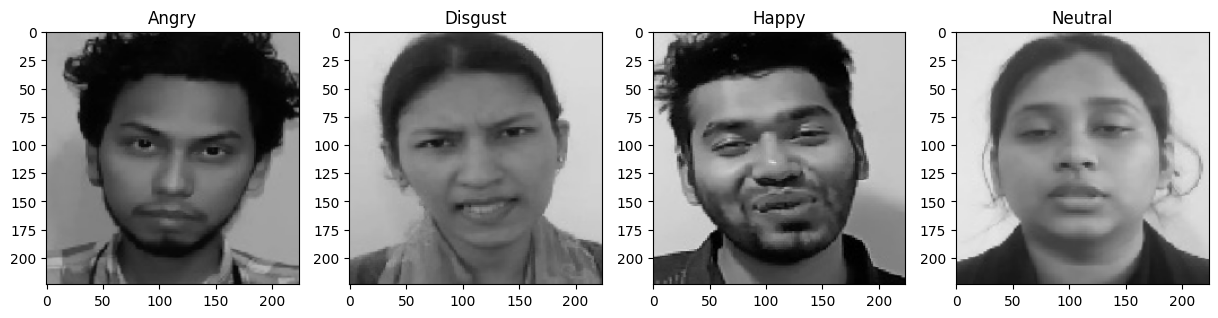

In [12]:
images, labels = next(train_generator)

# Plot four random images from the batch
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    # Generate a random index
    random_index = np.random.randint(0, BATCH_SIZE)
    
    # Plot the image
    axes[i].imshow(images[random_index])
    
    # Get the corresponding label
    label = labels[random_index]
    
    # Set the title as the class name
    class_name = train_generator.class_indices
    axes[i].set_title(list(class_name.keys())[np.argmax(label)])

plt.show()

In [13]:
from tensorflow.keras.callbacks import LearningRateScheduler


def scheduler(epoch, lr):
     if epoch < 10:
         return lr
     else:
        return lr * np.exp(-0.1)

lr_scheduler = LearningRateScheduler(scheduler)

In [14]:
if not os.path.exists("Results"):
    os.makedirs("Results")
if not os.path.exists("Model"):
    os.makedirs("Model") 
csv_logger_path = os.path.join("Results", f"image_vgg16_results.csv")
model_checkpoint_path = os.path.join("Model", f"image_vgg16_Model.hdf5")

In [15]:
csv_logger = CSVLogger(csv_logger_path)
early_stopping = EarlyStopping(monitor='val_loss', patience=patience)
check = ModelCheckpoint(model_checkpoint_path, verbose=1, save_best_only=True)
progbar_logger = ProgbarLogger()

In [16]:
history = model.fit(
    train_generator,
    epochs=50, 
    batch_size=32,
    validation_data=validation_generator,
    verbose = 1,
    callbacks = [early_stopping,lr_scheduler,check,csv_logger],
    initial_epoch=0
)

Epoch 1/50


504/504 [==============================] - ETA: 0s - loss: 0.6457 - accuracy: 0.7835
Epoch 1: val_loss improved from inf to 2.03854, saving model to Model\image_vgg16_Model.hdf5


c:\Python10\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


504/504 [==============================] - 3779s 7s/step - loss: 0.6457 - accuracy: 0.7835 - val_loss: 2.0385 - val_accuracy: 0.4408 - lr: 0.0010
Epoch 2/50
 22/504 [>.............................] - ETA: 43:19 - loss: 0.2655 - accuracy: 0.9233

In [15]:
# r = model.fit_generator(
#   training_set,
#   validation_data=test_set,
#   epochs=50,
#   steps_per_epoch=len(training_set),
#   validation_steps=len(test_set)
# )

C:\Users\ehsan\AppData\Local\Temp\ipykernel_6568\1167563505.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  r = model.fit_generator(


Epoch 1/50


 18/504 [>.............................] - ETA: 43:57 - loss: 2.5500 - accuracy: 0.2101

KeyboardInterrupt: 

In [2]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2,
                                  
        rotation_range=5,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1./255
                                  )

In [3]:
train_dataset  = train_datagen.flow_from_directory(directory = "E:\\Capstone\\Dataset\\Gray_Img\\train",
                                                   target_size = (64,64),
                                                   class_mode = 'categorical',
                                                   subset = 'training',
                                                   batch_size = 64)

Found 12900 images belonging to 7 classes.


In [4]:
valid_dataset = valid_datagen.flow_from_directory(directory ="E:\\Capstone\\Dataset\\Gray_Img\\train",
                                                  target_size = (64,64),
                                                  class_mode = 'categorical',
                                                  subset = 'validation',
                                                  batch_size = 64)

Found 3225 images belonging to 7 classes.


In [5]:
test_dataset = test_datagen.flow_from_directory(directory = "E:\\Capstone\\Dataset\\Gray_Img\\test",
                                                  target_size = (64,64),
                                                  class_mode = 'categorical',
                                                  batch_size = 64)

Found 4032 images belonging to 7 classes.


In [6]:
num_features = 64  # or any other value you want
width = 64
height = 64
num_classes = 7  # or whatever the number of classes in your problem is



In [7]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, Dropout, Flatten, Dense


In [41]:
base_model = tf.keras.applications.VGG16(input_shape=(64,64,3),include_top=False,weights="imagenet")

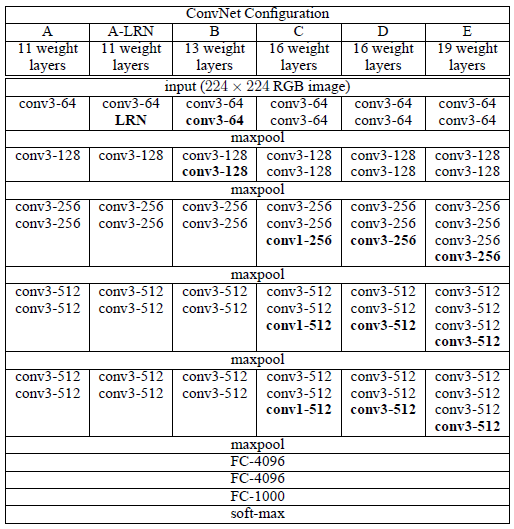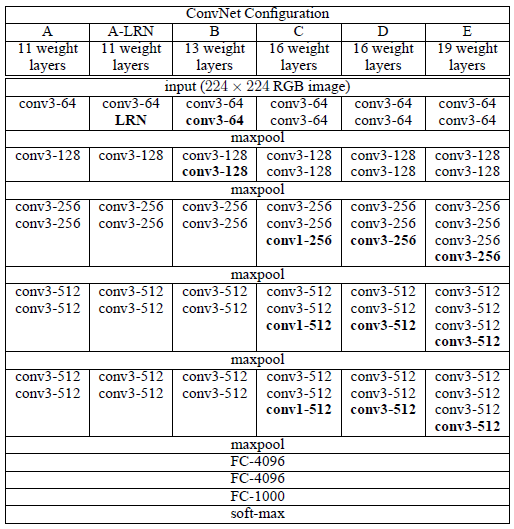

In [42]:
# # Building Model

# model=Sequential()
# model.add(base_model)
# model.add(Flatten())
# model.add(Dropout(0.2))
# model.add(Dense(64,activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(128,activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(7,activation='softmax'))

In [8]:
base_model = tf.keras.applications.VGG16(input_shape=(128, 128, 3), include_top=False, weights="imagenet")

In [12]:
#chatgpt
model = Sequential()
Conv2D(512, (3, 3), activation='relu', padding='same'),
MaxPooling2D((2, 2)),
Conv2D(512, (3, 3), activation='relu', padding='same'),
MaxPooling2D((2, 2)),
Conv2D(512, (3, 3), activation='relu', padding='same'),
MaxPooling2D((2, 2)),
Flatten(),
Dropout(0.5),
Dense(256, activation='relu'),
Dropout(0.5),
Dense(7, activation='softmax')


In [9]:
# Building Model

model=Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(7,activation='softmax'))

In [11]:
# Model Summary
for layer in base_model.layers:
    layer.trainable=False
model.summary()

ValueError: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.

In [44]:
print(base_model.layers[18].trainable)

False


In [45]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [46]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),  
      tf.keras.metrics.AUC(name='auc'),
        f1_score,
]

In [47]:
lrd = ReduceLROnPlateau(monitor = 'val_loss',patience = 20,verbose = 1,factor = 0.50, min_lr = 1e-10)

mcp = ModelCheckpoint('vgg-16-model.h5')

es = EarlyStopping(verbose=1, patience=20)

In [48]:
model.compile(optimizer='Adam', loss='categorical_crossentropy',metrics=METRICS)

In [49]:
history=model.fit(train_dataset,validation_data=valid_dataset,epochs = 50,verbose = 1,callbacks=[lrd,mcp,es])

Epoch 1/50
202/202 [==============================] - 314s 2s/step - loss: 1.8865 - accuracy: 0.8572 - precision: 0.5574 - recall: 0.0026 - auc: 0.6002 - f1_score: 0.0051 - val_loss: 1.9083 - val_accuracy: 0.8571 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5750 - val_f1_score: 0.0000e+00 - lr: 0.0010
Epoch 2/50
202/202 [==============================] - 275s 1s/step - loss: 1.7466 - accuracy: 0.8587 - precision: 0.6308 - recall: 0.0264 - auc: 0.6937 - f1_score: 0.0494 - val_loss: 1.8699 - val_accuracy: 0.8605 - val_precision: 1.0000 - val_recall: 0.0236 - val_auc: 0.6242 - val_f1_score: 0.0448 - lr: 0.0010
Epoch 3/50
202/202 [==============================] - 276s 1s/step - loss: 1.6455 - accuracy: 0.8620 - precision: 0.6964 - recall: 0.0605 - auc: 0.7391 - f1_score: 0.1095 - val_loss: 2.0026 - val_accuracy: 0.8567 - val_precision: 0.4803 - val_recall: 0.0416 - val_auc: 0.5976 - val_f1_score: 0.0745 - lr: 0.0010
Epoch 4/50
202/202 [==============================] 

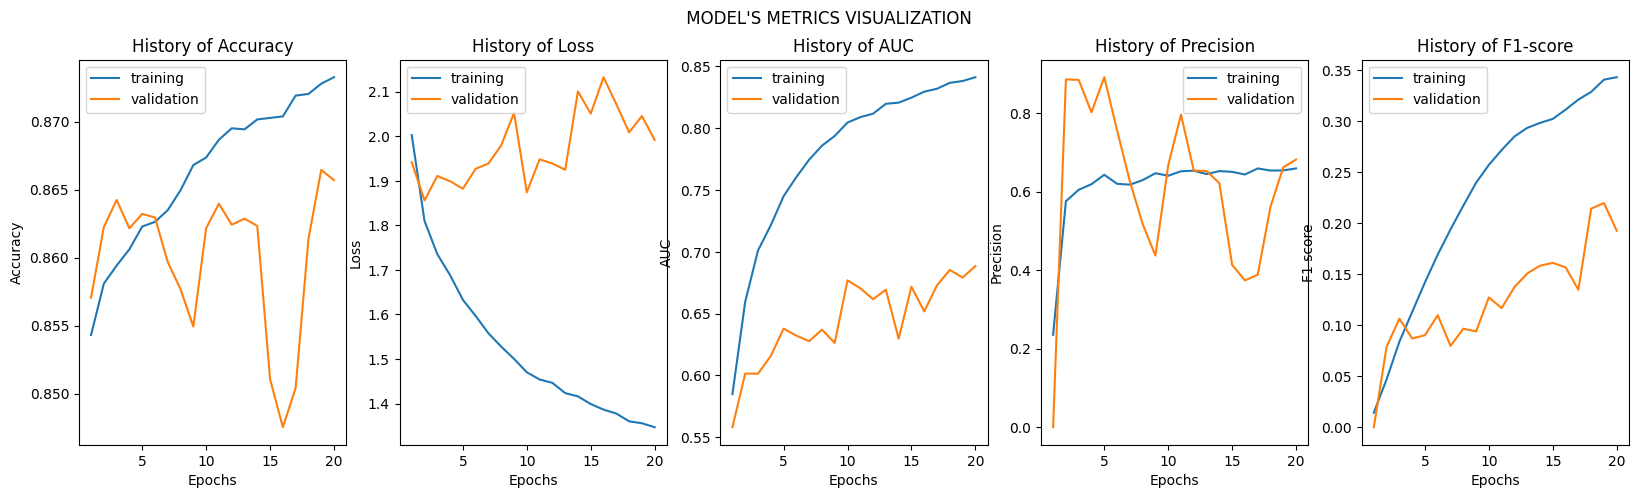

In [19]:
#%% PLOTTING RESULTS (Train vs Validation FOLDER 1)

def Train_Val_Plot(acc,val_acc,loss,val_loss,auc,val_auc,precision,val_precision,f1,val_f1):
    
    fig, (ax1, ax2,ax3,ax4,ax5) = plt.subplots(1,5, figsize= (20,5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    
    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.legend(['training', 'validation'])
    
    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.legend(['training', 'validation'])
    
    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.legend(['training', 'validation'])


    plt.show()
    

Train_Val_Plot(history.history['accuracy'],history.history['val_accuracy'],
               history.history['loss'],history.history['val_loss'],
               history.history['auc'],history.history['val_auc'],
               history.history['precision'],history.history['val_precision'],
               history.history['f1_score'],history.history['val_f1_score']
              )

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

2/2 [==============================] - 1s 466ms/step
Accuracy =  0.328125


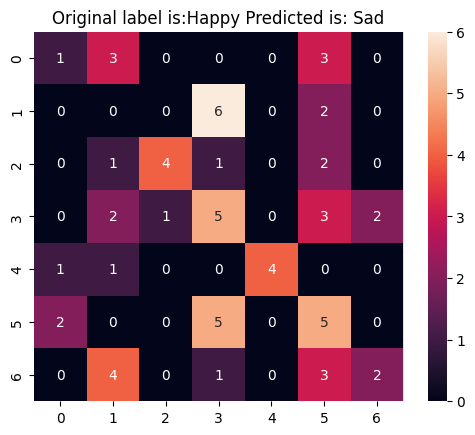

              precision    recall  f1-score   support

       angry       0.25      0.14      0.18         7
     disgust       0.00      0.00      0.00         8
        fear       0.80      0.50      0.62         8
       happy       0.28      0.38      0.32        13
     neutral       1.00      0.67      0.80         6
         sad       0.28      0.42      0.33        12
    surprise       0.50      0.20      0.29        10

    accuracy                           0.33        64
   macro avg       0.44      0.33      0.36        64
weighted avg       0.41      0.33      0.34        64



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import load_model
import random
#Test the model
my_model = load_model('vgg-16-model.h5', compile=False)

#Generate a batch of images
test_img, test_lbl = valid_dataset.__next__()
predictions=my_model.predict(test_img)

predictions = np.argmax(predictions, axis=1)
test_labels = np.argmax(test_lbl, axis=1)

from sklearn import metrics
print ("Accuracy = ", metrics.accuracy_score(test_labels, predictions))

#Confusion Matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predictions)
#print(cm)
import seaborn as sns
sns.heatmap(cm, annot=True)

class_labels=['Angry','Disgust', 'Fear', 'Happy','Neutral','Sad','Surprise']
#Check results on a few select images
n=random.randint(0, test_img.shape[0] - 1)
image = test_img[n]
orig_labl = class_labels[test_labels[n]]
pred_labl = class_labels[predictions[n]]
plt.imshow(image[:,:,0], cmap='gray')
plt.title("Original label is:"+orig_labl+" Predicted is: "+ pred_labl)
plt.show()


class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad','surprise']  # Replace with your actual class names
report = classification_report(test_labels, predictions, target_names=class_names, labels=range(len(class_names)))
print(report)